In [7]:
print("Missing values in X_tr:", X_tr.isnull().sum().sum())
print("Missing values in y_tr:", y_tr.isnull().sum())


Missing values in X_tr: 276
Missing values in y_tr: 0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
X_train = pd.read_csv('../../data/processed/X_train_processed.csv')
y_train = pd.read_csv('../../data/processed/y_train_processed.csv')['SalePrice']
X_test = pd.read_csv('../../data/processed/X_test_processed.csv')
test_ids = pd.read_csv('../../data/processed/test_ids.csv')['Id']

print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")


DATA LOADED SUCCESSFULLY
X_train shape: (1399, 244)
y_train shape: (1399,)
X_test shape: (1459, 244)


In [4]:
# Split into training and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=42
)

print("Data split completed!")
print("=" * 60)
print(f"Training set: {X_tr.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Split ratio: 80% train / 20% validation")


Data split completed!
Training set: 1119 samples
Validation set: 280 samples
Split ratio: 80% train / 20% validation


In [8]:
# Check for missing values
print("Checking for missing values...")
print("=" * 60)
print(f"Missing values in X_tr: {X_tr.isnull().sum().sum()}")
print(f"Missing values in X_val: {X_val.isnull().sum().sum()}")
print(f"Missing values in y_tr: {y_tr.isnull().sum()}")
print(f"Missing values in y_val: {y_val.isnull().sum()}")

# If there are missing values, impute them
if X_tr.isnull().sum().sum() > 0 or X_val.isnull().sum().sum() > 0:
    print("\n⚠️ Missing values detected! Imputing...")
    
    from sklearn.impute import SimpleImputer
    
    # Use median imputation for numerical features
    imputer = SimpleImputer(strategy='median')
    
    # Fit on training data and transform both train and validation
    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr), 
        columns=X_tr.columns,
        index=X_tr.index
    )
    X_val = pd.DataFrame(
        imputer.transform(X_val), 
        columns=X_val.columns,
        index=X_val.index
    )
    
    print("✅ Missing values imputed successfully!")
    print(f"Missing values in X_tr after imputation: {X_tr.isnull().sum().sum()}")
    print(f"Missing values in X_val after imputation: {X_val.isnull().sum().sum()}")
else:
    print("✅ No missing values detected!")


Checking for missing values...
Missing values in X_tr: 276
Missing values in X_val: 68
Missing values in y_tr: 0
Missing values in y_val: 0

⚠️ Missing values detected! Imputing...
✅ Missing values imputed successfully!
Missing values in X_tr after imputation: 0
Missing values in X_val after imputation: 0


In [5]:
# Initialize all models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10, random_state=42),
    'Lasso Regression': Lasso(alpha=0.001, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=1,
        random_state=42,
        n_jobs=-1
    )
}

print("Models initialized:")
print("=" * 60)
for i, name in enumerate(models.keys(), 1):
    print(f"{i}. {name}")


Models initialized:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Random Forest
5. XGBoost


In [9]:
# Dictionary to store results
results = {}
trained_models = {}

print("\n" + "=" * 60)
print("TRAINING MODELS")
print("=" * 60)

for name, model in models.items():
    print(f"\n{'─' * 60}")
    print(f"Training: {name}")
    print(f"{'─' * 60}")
    
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Make predictions
    y_train_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Store results
    results[name] = {
        'Train RMSE': train_rmse,
        'Validation RMSE': val_rmse,
        'Validation MAE': val_mae,
        'R² Score': val_r2
    }
    
    # Store trained model
    trained_models[name] = model
    
    # Print results
    print(f"  Train RMSE:      ${train_rmse:,.2f}")
    print(f"  Validation RMSE: ${val_rmse:,.2f}")
    print(f"  Validation MAE:  ${val_mae:,.2f}")
    print(f"  R² Score:        {val_r2:.4f}")
    print(f"  ✓ Training completed!")

print("\n" + "=" * 60)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
print("=" * 60)



TRAINING MODELS

────────────────────────────────────────────────────────────
Training: Linear Regression
────────────────────────────────────────────────────────────
  Train RMSE:      $14,338.29
  Validation RMSE: $56,362.61
  Validation MAE:  $17,577.57
  R² Score:        0.0013
  ✓ Training completed!

────────────────────────────────────────────────────────────
Training: Ridge Regression
────────────────────────────────────────────────────────────
  Train RMSE:      $15,148.27
  Validation RMSE: $31,294.97
  Validation MAE:  $14,884.52
  R² Score:        0.6921
  ✓ Training completed!

────────────────────────────────────────────────────────────
Training: Lasso Regression
────────────────────────────────────────────────────────────
  Train RMSE:      $14,338.30
  Validation RMSE: $56,338.14
  Validation MAE:  $17,554.56
  R² Score:        0.0021
  ✓ Training completed!

────────────────────────────────────────────────────────────
Training: Random Forest
──────────────────────────

In [10]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R² Score', ascending=False)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
display(results_df)

# Save results
results_df.to_csv('../../data/processed/model_comparison.csv')
print("\n✓ Results saved to 'data/processed/model_comparison.csv'")

# Identify best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {results_df.loc[best_model_name, 'R² Score']:.4f}")
print(f"   Validation RMSE: ${results_df.loc[best_model_name, 'Validation RMSE']:,.2f}")



MODEL PERFORMANCE COMPARISON


,Train RMSE,Validation RMSE,Validation MAE,R² Score
XGBoost,6254.721097,18517.383832,12381.275391,0.892200
Random Forest,10218.818275,21002.568081,14414.073512,0.861322
Ridge Regression,15148.272420,31294.967649,14884.520142,0.692100
Lasso Regression,14338.295764,56338.136467,17554.557565,0.002148
Linear Regression,14338.290077,56362.612306,17577.568499,0.001281



✓ Results saved to 'data/processed/model_comparison.csv'

🏆 Best Model: XGBoost
   R² Score: 0.8922
   Validation RMSE: $18,517.38


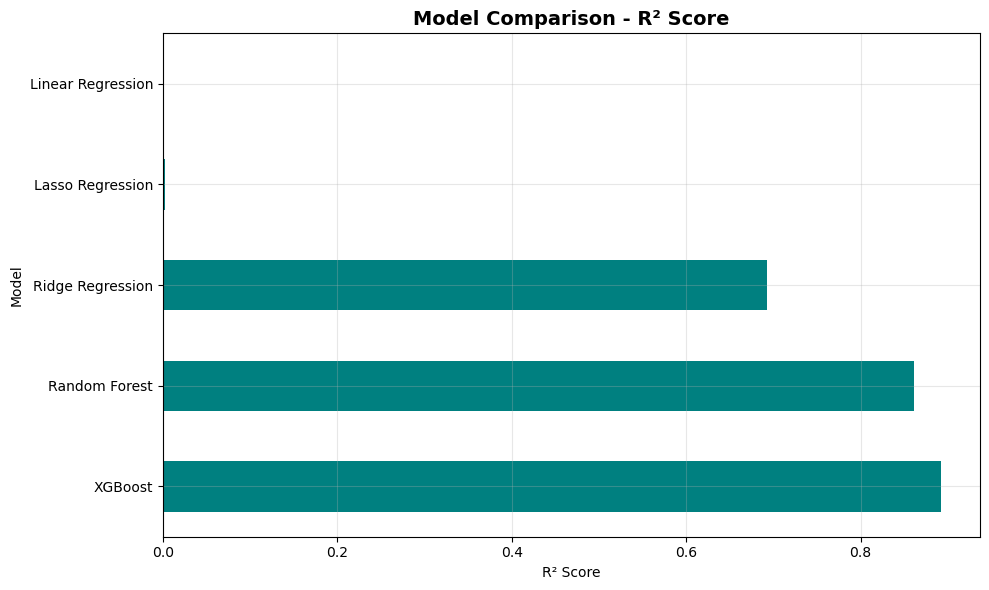

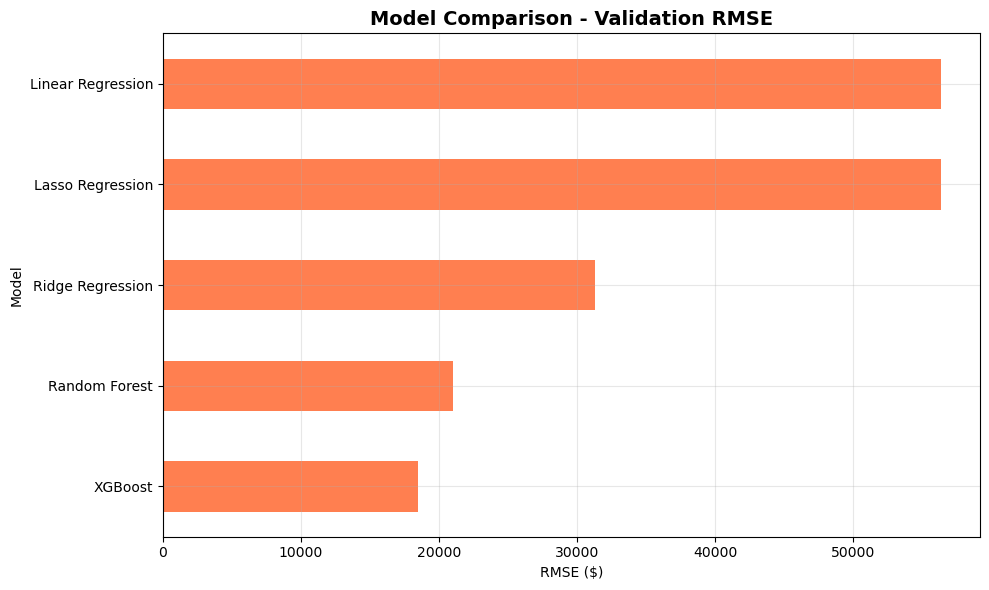

✓ Visualizations saved!


In [11]:
# Bar plot of R² scores
plt.figure(figsize=(10, 6))
results_df['R² Score'].plot(kind='barh', color='teal')
plt.title('Model Comparison - R² Score', fontsize=14, fontweight='bold')
plt.xlabel('R² Score')
plt.ylabel('Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../visualizations/model_comparison_r2.png', dpi=300, bbox_inches='tight')
plt.show()

# Bar plot of RMSE
plt.figure(figsize=(10, 6))
results_df['Validation RMSE'].plot(kind='barh', color='coral')
plt.title('Model Comparison - Validation RMSE', fontsize=14, fontweight='bold')
plt.xlabel('RMSE ($)')
plt.ylabel('Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../visualizations/model_comparison_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations saved!")


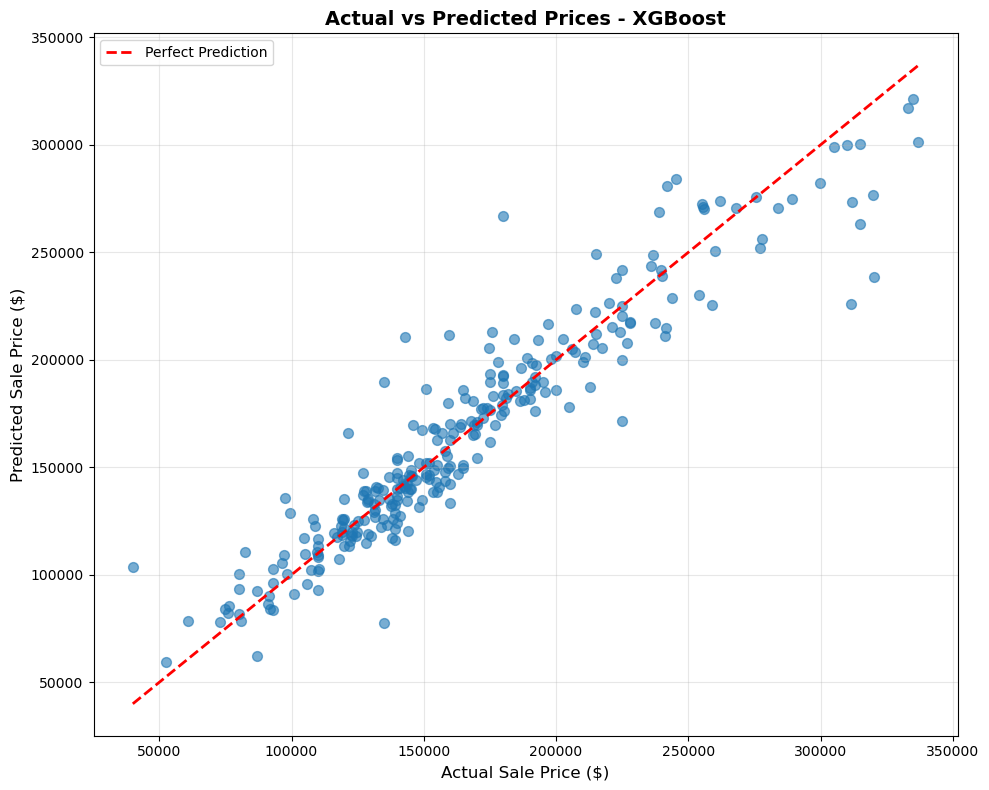

✓ Prediction plot saved!


In [12]:
# Get predictions from best model
y_val_pred_best = best_model.predict(X_val)

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_val, y_val_pred_best, alpha=0.6, s=50)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title(f'Actual vs Predicted Prices - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../visualizations/predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Prediction plot saved!")


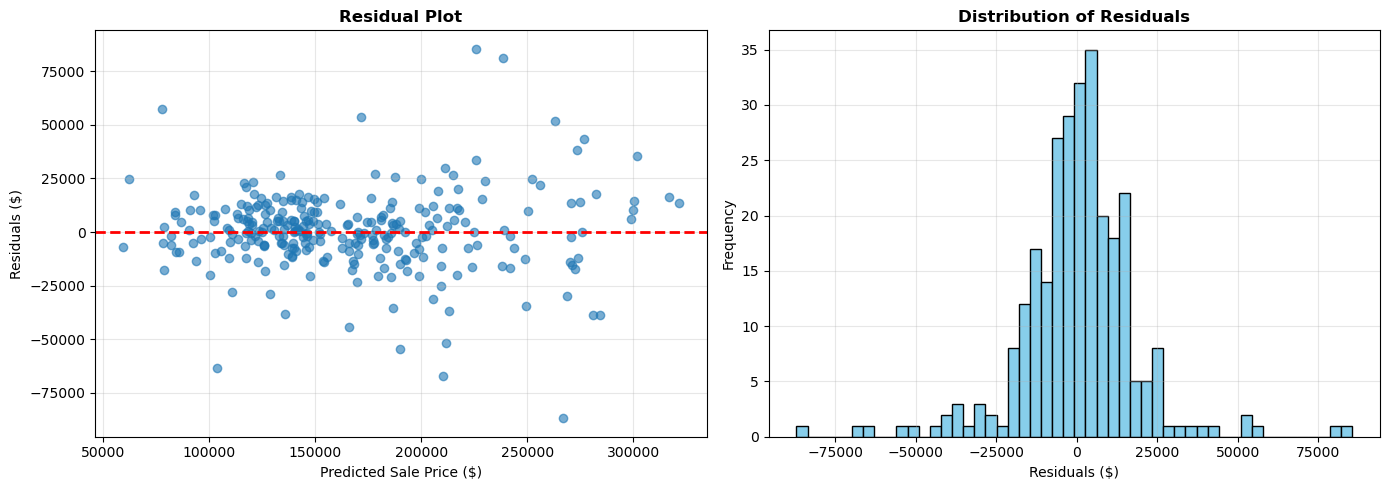

✓ Residual analysis saved!


In [13]:
# Calculate residuals
residuals = y_val - y_val_pred_best

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_val_pred_best, residuals, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Sale Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residual Plot', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=50, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Residuals ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../visualizations/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Residual analysis saved!")


In [14]:
# Perform 5-fold cross-validation on best model
print(f"\nPerforming 5-Fold Cross-Validation on {best_model_name}...")
print("=" * 60)

cv_scores = cross_val_score(
    best_model, 
    X_train, 
    y_train, 
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

cv_scores = -cv_scores  # Convert to positive RMSE

print(f"\nCross-Validation RMSE Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: ${score:,.2f}")

print(f"\nAverage CV RMSE: ${cv_scores.mean():,.2f}")
print(f"Standard Deviation: ${cv_scores.std():,.2f}")
print(f"95% Confidence Interval: ${cv_scores.mean():,.2f} ± ${cv_scores.std() * 2:,.2f}")



Performing 5-Fold Cross-Validation on XGBoost...

Cross-Validation RMSE Scores:
  Fold 1: $19,620.54
  Fold 2: $19,539.36
  Fold 3: $18,017.06
  Fold 4: $17,370.41
  Fold 5: $19,992.28

Average CV RMSE: $18,907.93
Standard Deviation: $1,023.72
95% Confidence Interval: $18,907.93 ± $2,047.43


In [15]:
# Train best model on full training data
print(f"\nRetraining {best_model_name} on full training data...")
best_model.fit(X_train, y_train)

# Make predictions on test set
test_predictions = best_model.predict(X_test)

print(f"✓ Predictions generated for {len(test_predictions)} houses")
print(f"\nPrediction Statistics:")
print(f"  Mean: ${test_predictions.mean():,.2f}")
print(f"  Median: ${np.median(test_predictions):,.2f}")
print(f"  Min: ${test_predictions.min():,.2f}")
print(f"  Max: ${test_predictions.max():,.2f}")



Retraining XGBoost on full training data...
✓ Predictions generated for 1459 houses

Prediction Statistics:
  Mean: $172,835.52
  Median: $158,246.17
  Min: $40,688.97
  Max: $348,230.53


In [16]:
# Create submission DataFrame
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions
})

# Save to CSV
submission.to_csv('../../data/processed/house_price_predictions.csv', index=False)

print("=" * 60)
print("✅ SUBMISSION FILE CREATED")
print("=" * 60)
print(f"File saved: data/processed/house_price_predictions.csv")
print(f"Total predictions: {len(submission)}")
print("\nFirst 10 predictions:")
display(submission.head(10))


✅ SUBMISSION FILE CREATED
File saved: data/processed/house_price_predictions.csv
Total predictions: 1459

First 10 predictions:


,Id,SalePrice
0,1461,128302.960938
1,1462,160915.796875
2,1463,188079.984375
3,1464,187157.359375
4,1465,179653.937500
5,1466,173655.453125
6,1467,172101.828125
7,1468,167562.421875
8,1469,187841.437500
9,1470,129257.062500


In [17]:
# Save the best trained model
model_filename = f'../../models/{best_model_name.replace(" ", "_").lower()}_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

print(f"✓ Best model saved: {model_filename}")

# Save model metadata
metadata = {
    'Model Name': best_model_name,
    'R² Score': results_df.loc[best_model_name, 'R² Score'],
    'Validation RMSE': results_df.loc[best_model_name, 'Validation RMSE'],
    'Validation MAE': results_df.loc[best_model_name, 'Validation MAE'],
    'Cross-Validation RMSE Mean': cv_scores.mean(),
    'Cross-Validation RMSE Std': cv_scores.std(),
    'Features': X_train.shape[1],
    'Training Samples': X_train.shape[0]
}

metadata_df = pd.DataFrame(metadata.items(), columns=['Metric', 'Value'])
metadata_df.to_csv('../../models/best_model_metadata.csv', index=False)

print("✓ Model metadata saved: models/best_model_metadata.csv")

print("\n" + "=" * 60)
print("✅ MODEL TRAINING AND EVALUATION COMPLETED!")
print("=" * 60)


✓ Best model saved: ../../models/xgboost_model.pkl
✓ Model metadata saved: models/best_model_metadata.csv

✅ MODEL TRAINING AND EVALUATION COMPLETED!
